# Matching Exercise 

You have been hired by a mortgage firm (a company that both issues and collects mortgage payments from homeowners). This servicing firm is thinking about entering the market for "no money down" mortgages — mortgages in which the buyer does not have to pay a large percentage of the value of the house when they take out the loan (in the US, most people pay 20% of the value of a house up front when taking out a mortgage). Instead, they just pay a slightly higher interest rate.

Before they start offering this product, though, they want to know the effect this option will have on the likelihood people who take out a mortgage from them will make their payments. In other words, they want to know:

**What is the effect of a mortgage being issued as a "no money down" mortgage on the likelihood that the mortgage will enter delinquency (the homeowner will be at least 30 days late on a mortgage payment) during the first two years of the mortgage?**

On the one hand, we might expect that someone taking out a "no money down" mortgage would be *less* likely to enter delinquency because they didn't have to put a lot of cash into a down payment, making it easier for them to afford their payments. 

On the other hand, the kind of people who can put 20% down on a house are the kind of people who are able to save effectively, so someone who opts for a "no money down" mortgage with a higher interest rate (instead of saving to pay the 20% down payment) may be more likely to also struggle to make their regular payments. 

### Data

To answer this question, you have been given [REAL data on a sample of all US Standard single family home mortgages purchased or insured by Freddie Mac](https://www.freddiemac.com/research/datasets/sf-loanlevel-dataset). This is a random sample of standard mortgages issued in the calendar year 2004.


## Gradescope Autograding

Please follow [all standard guidance](https://www.practicaldatascience.org/ids720_specific/autograder_guidelines.html) for submitting this assignment to the Gradescope autograder, including storing your solutions in a dictionary called `results` and ensuring your notebook runs from the start to completion without any errors.

For this assignment, please name your file `exercise_matching.ipynb` before uploading.

You can check that you have answers for all questions in your `results` dictionary with this code:

```python
assert set(results.keys()) == {
    "ex2_share_nmd",
    "ex3_shr_delinquent_nmd",
    "ex3_shr_delinquent_regular",
    "ex6_nmd_regression",
    "ex9_least_balanced",
    "ex11_num_matches",
    "ex11_num_no_money_down",
    "ex12_bivariate_effect",
    "ex13_withcoefficients_effect",
}
```

### Submission Limits

Please remember that you are **only allowed THREE submissions to the autograder.** Your last submission (if you submit 3 or fewer times), or your third submission (if you submit more than 3 times) will determine your grade Submissions that error out will **not** count against this total.

## Data Prep

### Exercise 1

To save you some time and let you focus on matching, I've done some pre-cleaning of this data a little. Later on this semester I'll ask you to work with a raw-er and more complete version of this data, but for now, please download the mortgage data here from [https://github.com/nickeubank/MIDS_Data/raw/refs/heads/master/mortgages/exercise_matching/standard_mortgages.parquet](https://github.com/nickeubank/MIDS_Data/raw/refs/heads/master/mortgages/exercise_matching/standard_mortgages.parquet).


In [2]:
import pandas as pd

pd.set_option("mode.copy_on_write", True)

url = "https://github.com/nickeubank/MIDS_Data/raw/refs/heads/master/mortgages/exercise_matching/standard_mortgages.parquet"

df = pd.read_parquet(url, engine="pyarrow")

df.head()

,Loan Sequence Number,Original Loan-to-Value (LTV),Original UPB,Original Loan Term,Credit Score,First Payment Date,First Time Homebuyer Flag,Original Interest Rate,Metropolitan Statistical Area (MSA) Or Metropolitan Division,Postal Code,delinquent
0,F04Q10000054,87,127000,360,653,200403,Y,6.050,20740.0,54700,0
1,F04Q10000200,70,121000,360,747,200403,N,6.125,30700.0,68500,0
2,F04Q10000236,80,286000,180,731,200403,N,5.125,NaN,60500,0
3,F04Q10000281,80,114000,180,682,200403,N,5.500,NaN,47100,0
4,F04Q10000296,80,132000,360,730,200403,N,5.750,NaN,81200,0


### Exercise 2

`Original Loan-to-Value (LTV)` is the share of the original value of the home that was borrowed. A value of 100 means there was no down payment ("no money down"), while higher values indicate a down payment was made. 

If you look at the values of `Original Loan-to-Value (LTV)` in the data, you will see there is a distribution of values. *Truly* no money down mortgages are actually pretty rare — about 1.4% of mortgages — but *almost* no money down mortgages (mortgages where the borrower only pays a 5% down payment) are a lot more common (about 10% of mortgages). So let's focus our analysis on those 95% LTV mortgages — they aren't *quite* no money down, but they're pretty close. From this point forward, when I say "no-money-down mortgages," I mean 95% LTV mortgages.

To keep things simple, let's compare these (almost) no money down mortgages to mortgages with a 20% down payment (LTV value of 80). This is the modal mortgage in the US. 

Once you've limited your data to mortgages with LTVs of 95% and 80%, what share of the mortgages you still have were no-money-down (LTV 95%) mortgages? Store your answer under the key `"ex2_share_nmd"`.

In [ ]:
results = {}

df_filtered = df[df["Original Loan-to-Value (LTV)"].isin([80, 95])]

share_nmd = (df_filtered["Original Loan-to-Value (LTV)"] == 95).mean()

results["ex2_share_nmd"] = share_nmd

print(results["ex2_share_nmd"])

0.19942642841385397


### Exercise 3

Now let's see how delinquency rates compare between regular and no-money-down mortgages. Store the share of mortgages that are ever delinquent under the keys `"ex3_shr_delinquent_regular"` and `"ex3_shr_delinquent_nmd"`

In [ ]:
# 1. Calculate the share for regular (80% LTV) mortgages
shr_delinquent_regular = df_filtered[df_filtered["Original Loan-to-Value (LTV)"] == 80][
    "delinquent"
].mean()

# 2. Calculate the share for no money down (95% LTV) mortgages
shr_delinquent_nmd = df_filtered[df_filtered["Original Loan-to-Value (LTV)"] == 95][
    "delinquent"
].mean()

results["ex3_shr_delinquent_regular"] = shr_delinquent_regular
results["ex3_shr_delinquent_nmd"] = shr_delinquent_nmd

print(results["ex3_shr_delinquent_regular"])
print(results["ex3_shr_delinquent_nmd"])

0.06337834114081015
0.1338495575221239


### Exercise 4

Now, is this difference the result of not having to put money down, or is it the result of different lending standards? 

Let's take a look at a few descriptive statistics to try and answer this question. 

First, plot two histograms on the same plot — one with the credit score for regular mortgage borrowers, and one with the credit score for no-money-down mortgage borrowers. Then do the same with the size of the mortgage (`"Original UPB"`) and original interest rates (`"Original Interest Rate"`).

Make sure you're plotting densities not frequencies. 

Do these look like the same borrowers? (High credit scores mean people are deemed to be at lower risk of defaulting on their loans).

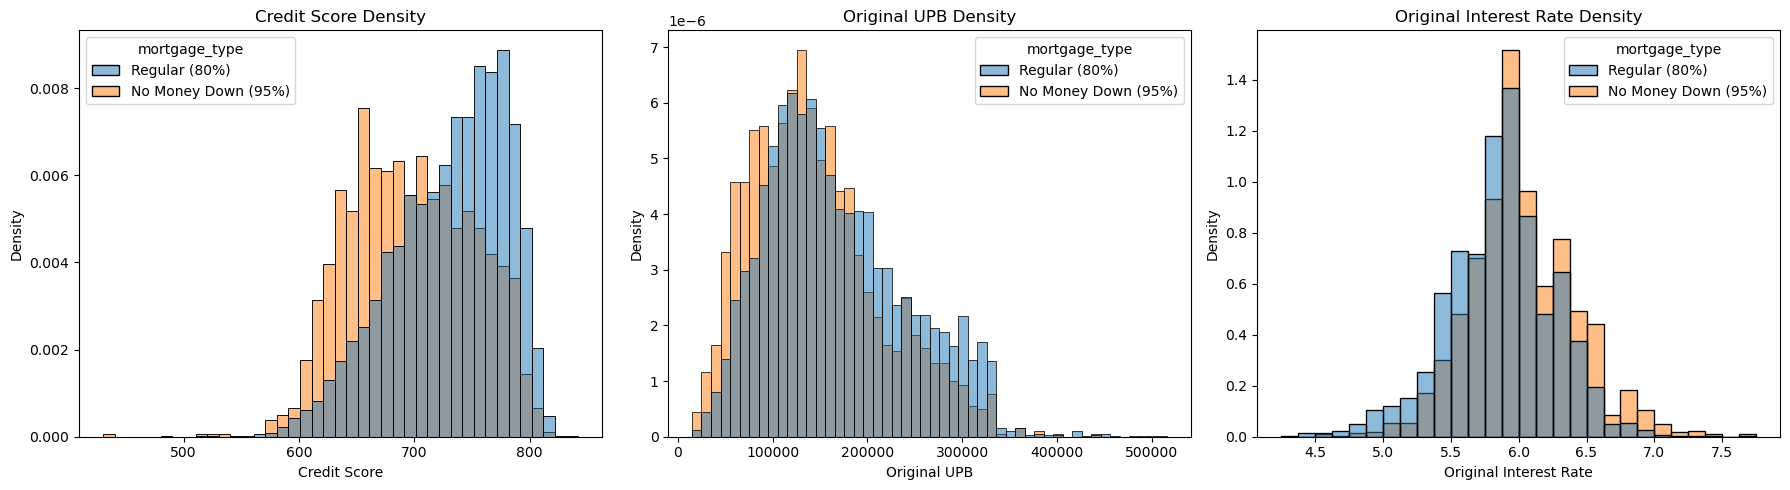

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_filtered["mortgage_type"] = df_filtered["Original Loan-to-Value (LTV)"].map(
    {80: "Regular (80%)", 95: "No Money Down (95%)"}
)

# Set up the figure layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Credit Score
sns.histplot(
    data=df_filtered,
    x="Credit Score",
    hue="mortgage_type",
    stat="density",
    common_norm=False,
    ax=axes[0],
    alpha=0.5,
    binwidth=10,
)
axes[0].set_title("Credit Score Density")

# 2. Original UPB
sns.histplot(
    data=df_filtered,
    x="Original UPB",
    hue="mortgage_type",
    stat="density",
    common_norm=False,
    ax=axes[1],
    alpha=0.5,
    binwidth=10000,
)
axes[1].set_title("Original UPB Density")

# 3. Original Interest Rate
sns.histplot(
    data=df_filtered,
    x="Original Interest Rate",
    hue="mortgage_type",
    stat="density",
    common_norm=False,
    ax=axes[2],
    alpha=0.5,
    binwidth=0.125,
)
axes[2].set_title("Original Interest Rate Density")

plt.tight_layout()
plt.show()

- Credit Score Density: The No Money Down borrowers (orange) have a distribution that is noticeably shifted to the left compared to the Regular borrowers (blue). This indicates they generally have lower credit scores and are therefore deemed to be higher risk.

- Original UPB Density: The mortgage sizes are a bit more similar, but the Regular borrowers have a slightly thicker tail on the right side of the distribution. This suggests the regular borrowers are more likely to take out exceptionally large loans compared to the No Money Down group.

- Original Interest Rate Density: The orange distribution is shifted slightly to the right. This aligns perfectly with standard banking risk models. Since the No Money Down borrowers have lower credit scores and are putting less equity into the home, lenders charge them higher interest rates to compensate for the increased default risk.

### Exercise 5

Matching brings value when you have an imbalance in covariates between your control and treatment groups. At the same time, matching only works when there isn't too much imbalance — you need an area of "common support" where you have both control and treatment observations for certain ranges of your covariates. 

Looking back at your results from Exercise 4, does it seem like this data might be a good candidate for matching?

This data is an excellent candidate for matching.

- Imbalance is present: Matching is valuable specifically when the treatment and control groups have different baseline characteristics. As we discussed, the No Money Down borrowers have noticeably different credit scores and interest rates compared to the Regular borrowers.

- Common support is strong: For matching to actually work, we need an area of "common support". This simply means the distributions must overlap enough that we can actually find comparable individuals in both groups. Looking at our plots, the overlap is massive. There are plenty of Regular borrowers with credit scores in the 650 range to match against the No Money Down borrowers, and plenty of No Money Down borrowers in the 750 range to match against the Regular borrowers.

### Exercise 6

To establish a baseline of sorts, regress your "delinquent" variable on:

- whether the loan is a no-money-down mortgage, 
- borrower credit score,
- whether borrower is a first time home buyer, and 
- the original interest rate. 

**Drop observations where first-time home buyer is `9` and use this restricted sample moving forward.**

Use a linear model and (because the dependent variable is 0-1) heteroskedastic robust standard errors. Store the estimated effect of a mortgage being no-money-down (the coefficient on no-money-down indicator) in `results` under the key `ex6_nmd_regression`.

(Note: if you use the formula api from statsmodels, you may have to change some variable names)

In [ ]:
import statsmodels.formula.api as smf

# 1. Filter
df_clean = df_filtered[
    (df_filtered["First Time Homebuyer Flag"] != "9")
    & (df_filtered["First Time Homebuyer Flag"] != 9)
].copy()

# 2. Create the no-money-down binary indicator for the regression
df_clean["no_money_down"] = (df_clean["Original Loan-to-Value (LTV)"] == 95).astype(int)

# 3. Define the formula API string
formula = 'delinquent ~ no_money_down + Q("Credit Score") + Q("First Time Homebuyer Flag") + Q("Original Interest Rate")'

# 4. Fit the linear model with robust standard errors
baseline_model = smf.ols(formula=formula, data=df_clean)
baseline_results = baseline_model.fit(cov_type="HC1")

# Print the summary
print(baseline_results.summary())

results["ex6_nmd_regression"] = baseline_results.params["no_money_down"]

                            OLS Regression Results                            
Dep. Variable:             delinquent   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     66.66
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           1.13e-55
Time:                        22:01:54   Log-Likelihood:                -695.44
No. Observations:                9063   AIC:                             1401.
Df Residuals:                    9058   BIC:                             1436.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

### Exercise 7

Matching is great because of its ability to reduce dependence on functional form assumptions (do you assume the dependent variable increases linearly with the dependent variable, or the log of the dependent variable, or the square, etc.). This is most powerful where there is some "extrapolation" taking place because of an imbalance in covariates, because there's no good way to validate those extrapolations. But it also simplifies the general problem of worrying about function forms.

To illustrate, we just fit our model with a range of covariates included as linear controls. But do we know that delinquency decreases linearly with credit scores? 

Just looking at delinquency and credit scores, fit a lowess regression (or other model with a flexible functional form) to see if that relationship is indeed linear. 

Now do the same for delinquency and the original interest rate. Does that seem linear?

What does this tell you about the accuracy of your regression estimates above?

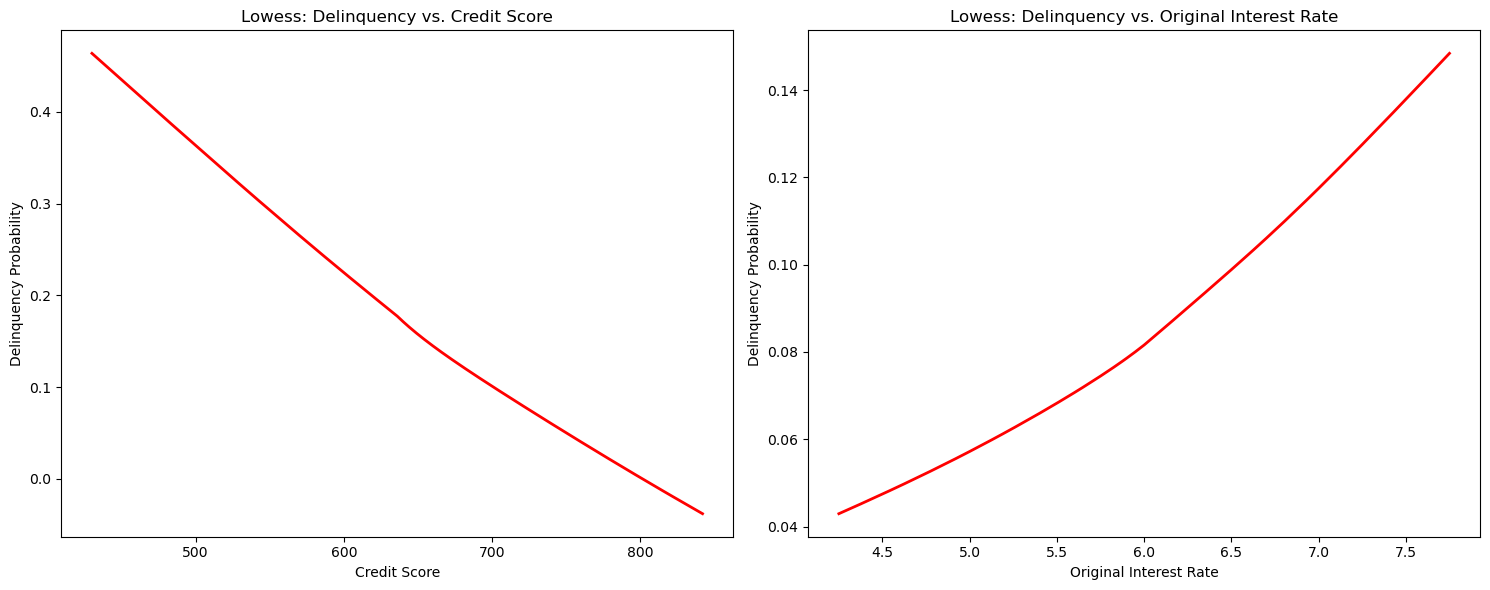

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Delinquency vs Credit Score
lowess_cs = sm.nonparametric.lowess(
    df_clean["delinquent"], df_clean["Credit Score"], frac=1, it=0
)
axes[0].plot(lowess_cs[:, 0], lowess_cs[:, 1], color="red", linewidth=2)
axes[0].set_title("Lowess: Delinquency vs. Credit Score")
axes[0].set_xlabel("Credit Score")
axes[0].set_ylabel("Delinquency Probability")

# 2. Delinquency vs Original Interest Rate
lowess_ir = sm.nonparametric.lowess(
    df_clean["delinquent"], df_clean["Original Interest Rate"], frac=1, it=0
)
axes[1].plot(lowess_ir[:, 0], lowess_ir[:, 1], color="red", linewidth=2)
axes[1].set_title("Lowess: Delinquency vs. Original Interest Rate")
axes[1].set_xlabel("Original Interest Rate")
axes[1].set_ylabel("Delinquency Probability")

plt.tight_layout()
plt.show()

- Do they seem linear? 

    - Credit Score: While it looks somewhat like a straight line, we can see a slight curve to it. Also, notice how the line actually dips below 0.0 at the highest credit scores. In reality, a probability can never be less than zero. This is a classic indicator that a strict linear assumption doesn't perfectly fit the reality of the data.

    - Original Interest Rate: This one is much more obviously non-linear. It has a distinct "bow" or exponential curve to it. As interest rates get higher, the probability of delinquency accelerates upwards.

- What does this tell you about the accuracy of your regression estimates above?

    - Because the true relationships (especially for interest rates) are curved, the linear regression we ran in Exercise 6 (which forces a perfectly straight line through the data) is mathematically forced to make errors. It will likely underestimate delinquency risk in some areas and overestimate it in others.

    - This perfectly highlights the value of matching! By using matching instead of a rigid linear regression, we don't have to worry about whether the "functional form" is a straight line, a log curve, or a polynomial. We just compare similar people directly.

## Matching!

OK, let's finally do some matching!

To do our matching, we will be using pymatchit, a port of the exceptionally good [MatchIt](https://kosukeimai.github.io/MatchIt/index.html) which is only natively available in R. [It supports genetic matching, exact matching, coarsened exact matching, nearest neighbor matching, subclass matching, cardinality matching, and more.](https://kosukeimai.github.io/MatchIt/articles/matching-methods.html). 

This library was just recently created (and I have to imagine with significant LLM help), so it's a little early to be using it. With that said, matching is one area where R packages (namely MatchIt) are still well ahead of Python libraries, and after looking things over pretty carefully it seems well implemented — it has a reasonable test suite, includes diagnostic plots (which are something that's so often missing from Python matching and are great for learning), and testing the matching algorithm we're using (coarse exact matching) things seem to match between R and this package. So let's try it. :)

So install it with `pip install pymatchit-causal` (**not** `pip install pymatchit`), and quickly review the [README for the repo here](https://github.com/jtuenner/).


### Exercise 8

Let's do some coarsened exact matching. 

In particular, we will match on `credit_score`, `original_interest_rate`, and `first_time_homebuyer_flag`.

Recall that with coarsened exact matching, we have to specify how continuous variables (like `credit_score` and `original_interest_rate`) should be coarsened. This is accomplished with the `cutpoints` keyword. Note the `cutpoints` takes the upper and lower values to be bounds — so `[1, 2, 3]` will create two groups: between 1 and 2 and between 2 and 3. Values below 1 and above 3 will be dropped.

```python
from pymatchit import MatchIt

mortgages["first_time"] = (mortgages["first_time_homebuyer_flag"] == "Y").astype("int")

# Deterministic sort to ensure
# random seed generates same result
mortgages = mortgages.sort_values("loan_sequence_number")

m = MatchIt(
    data=mortgages,
    method="cem",
    replace=False,
    random_state=42,
    estimand="ATE",
    cutpoints={
        "credit_score": [500, 575, 650, 675, 700, 720, 740, 760, 780, 800],
        "original_interest_rate": [4.25, 5.25, 6.25, 7.25, 8.25],
    },
)


# Format: treatment_variable ~ covariate1 + covariate2 + ...
m.fit("no_money_down ~ credit_score + original_interest_rate " "+ first_time")

```



In [ ]:
from pymatchit import MatchIt

# 1. Create formatted columns to avoid formula parsing errors with spaces
df_clean["credit_score"] = df_clean["Credit Score"]
df_clean["original_interest_rate"] = df_clean["Original Interest Rate"]

# Create the first time homebuyer binary indicator
df_clean["first_time"] = (df_clean["First Time Homebuyer Flag"] == "Y").astype(int)

# 2. Sort deterministically to ensure the random seed generates the exact same result
df_clean = df_clean.sort_values("Loan Sequence Number")

# 3. Initialize the MatchIt model with the specified cutpoints
m = MatchIt(
    data=df_clean,
    method="cem",
    replace=False,
    random_state=42,
    estimand="ATE",
    cutpoints={
        "credit_score": [500, 575, 650, 675, 700, 720, 740, 760, 780, 800],
        "original_interest_rate": [4.25, 5.25, 6.25, 7.25, 8.25],
    },
)

# 4. Fit the matching model
m.fit("no_money_down ~ credit_score + original_interest_rate + first_time")

Performing cem matching (ATE)...
Matching complete. 8819 observations in matched set.


### Exercise 9

The first thing to do after matching is to see if the merge worked well. 

Use `m.plot(type="balance", threshold=0.2)` to see how balanced the matched coefficients look. Which variable appears not to be that well balanced in the matched data? Store your answer as a string in `"ex9_least_balanced"`

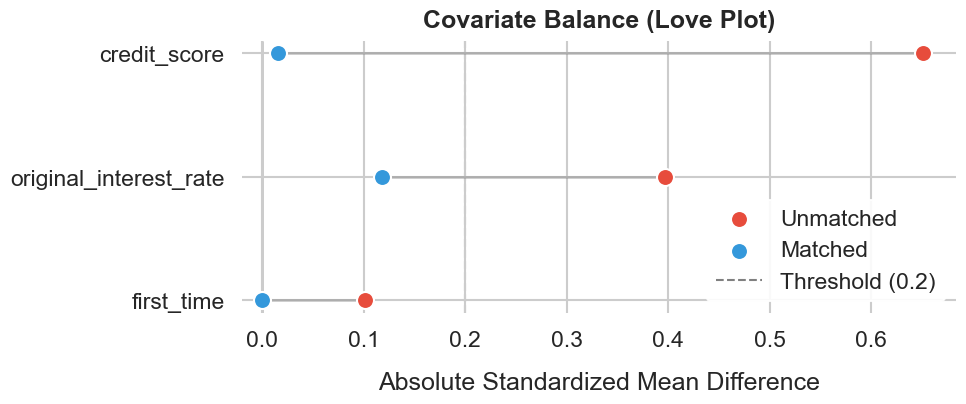

In [14]:
m.plot(type="balance", threshold=0.2)
plt.show()

In [15]:
results["ex9_least_balanced"] = "original_interest_rate"

### Exercise 10

Let's tighten up our cutpoints to try and get better matches on interest rates. Try:

```python

cutpoints={
    "credit_score": [500, 575, 650, 675, 700, 720, 740, 760, 780, 800],
    "original_interest_rate": np.arange(4.25, 8.1, 0.1),
}

```

Then check your balance plot.

Performing cem matching (ATE)...
Matching complete. 8430 observations in matched set.


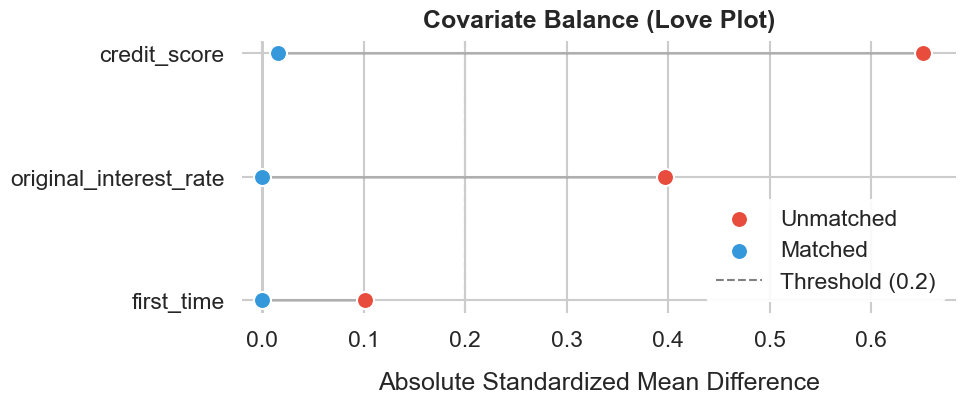

In [ ]:
import numpy as np

# 1. Initialize the MatchIt model with the tighter interest rate cutpoints
m_tight_rate = MatchIt(
    data=df_clean,
    method="cem",
    replace=False,
    random_state=42,
    estimand="ATE",
    cutpoints={
        "credit_score": [500, 575, 650, 675, 700, 720, 740, 760, 780, 800],
        "original_interest_rate": np.arange(4.25, 8.1, 0.1),
    },
)

# 2. Fit the new model
m_tight_rate.fit("no_money_down ~ credit_score + original_interest_rate + first_time")

# 3. Check the balance plot again
m_tight_rate.plot(type="balance", threshold=0.2)
plt.show()

### Exercise 11

Given we're still getting a lot of matched observations, so let's tighten credit ratings too! Try:

```python
cutpoints = {
    "credit_score": np.arange(500, 800, 20),
    "original_interest_rate": np.arange(4.25, 8.1, 0.1),
}
```

Store your final number of matches in `ex11_num_matches` (you can get this from `len(m.matched_data)`) and the final number of matched treated units (no money down mortgages) in `"ex11_num_no_money_down"`.

In [ ]:
# 1. Initialize the final MatchIt model with both tightened cutpoints
m_final = MatchIt(
    data=df_clean,
    method="cem",
    replace=False,
    random_state=42,
    estimand="ATE",
    cutpoints={
        "credit_score": np.arange(500, 800, 20),
        "original_interest_rate": np.arange(4.25, 8.1, 0.1),
    },
)

# 2. Fit the final model
m_final.fit("no_money_down ~ credit_score + original_interest_rate + first_time")

# 3. Extract the matched dataset
matched_data = m_final.matched_data

# 4. Calculate the total number of matched observations
num_matches = len(matched_data)

# 5. Calculate the total number of matched treated units (no money down)
# Since 'no_money_down' is 1 for treated and 0 for control, we can just sum them or filter
num_no_money_down = len(matched_data[matched_data["no_money_down"] == 1])

results["ex11_num_matches"] = num_matches
results["ex11_num_no_money_down"] = num_no_money_down

print(f"Total matches: {num_matches}")
print(f"Treated matches (No Money Down): {num_no_money_down}")

Performing cem matching (ATE)...
Matching complete. 7484 observations in matched set.
Total matches: 7484
Treated matches (No Money Down): 1644


## Analyzing Matches

Assuming you feel ok with the matches at this point, let's do some analyses!

### Exercise 12

Using statsmodels, fit a weighted regression using the data in `m.matched_data` with just `no_money_down` as a regressor. Store the resulting coefficient in `"ex12_bivariate_effect"`.

Note that `pymatchit` can provide two different types of weights — weights for estimating ATE, and weights for estimating ATT. 

To estimate ATT, the weight of a treated (here, `no_money_down`) observation will always be 1, and the weight for a control observation will be the number of treatment observations in the coarse match group divided by the number of controls.

To estimate ATE, the weights are just the total observations in the coarse match group divided by number of treatment observations (for treated observations) and total observations in the coarse match group divided by the number of control observations (for control observations).

Here, we've specified the estimate is `"ATE"`, so we get weights for estimating ATE.


In [ ]:
import statsmodels.formula.api as smf

# 1. Extract the matched dataset from the final model
matched_df = m_final.matched_data

# 2. Fit the Weighted Least Squares (WLS) model with just the treatment variable
# We pass the automatically generated 'weights' column to the weights parameter
model_bivariate = smf.wls(
    formula="delinquent ~ no_money_down",
    data=matched_df,
    weights=matched_df["weights"],
)

# Fit with robust standard errors
results_bivariate = model_bivariate.fit(cov_type="HC1")

# Print the summary to see the treatment effect
print(results_bivariate.summary())

# 3. Store the estimated coefficient
results["ex12_bivariate_effect"] = results_bivariate.params["no_money_down"]

print(results["ex12_bivariate_effect"])

                            WLS Regression Results                            
Dep. Variable:             delinquent   R-squared:                       0.003
Model:                            WLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     10.10
Date:                Wed, 25 Feb 2026   Prob (F-statistic):            0.00149
Time:                        22:30:46   Log-Likelihood:                -1948.3
No. Observations:                7484   AIC:                             3901.
Df Residuals:                    7482   BIC:                             3914.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0727      0.004     20.148

### Exercise 13

Because not all our coefficients matched perfectly, its good practice to include the matching variables in your regression in their original form. So estimate your model again, this time with `no_money_down`, `credit_score`, `original_interest_rate` and `first_time` in the regression. Store the new estimated effect in `"ex13_withcoefficients_effect"`.

In [ ]:
# 1. Define the full formula with all covariates included
formula_full = (
    "delinquent ~ no_money_down + credit_score + original_interest_rate + first_time"
)

# 2. Fit the new WLS model
model_full = smf.wls(
    formula=formula_full, data=matched_df, weights=matched_df["weights"]
)

# Fit with robust standard errors
results_full = model_full.fit(cov_type="HC1")

# Print the summary to compare with the previous model
print(results_full.summary())

# 3. Store the new estimated effect
results["ex13_withcoefficients_effect"] = results_full.params["no_money_down"]

print(results["ex13_withcoefficients_effect"])

                            WLS Regression Results                            
Dep. Variable:             delinquent   R-squared:                       0.034
Model:                            WLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     35.32
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           2.86e-29
Time:                        22:31:36   Log-Likelihood:                -1830.3
No. Observations:                7484   AIC:                             3671.
Df Residuals:                    7479   BIC:                             3705.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0